In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')
# Инициализация JS для красивых графиков SHAP в ноутбуке
shap.initjs()

In [2]:
# Загрузка данных
path = '/kaggle/input/datasets/eclipse8n/aiindrivefile20251/AIinDrivefile20251.xlsx'
df = pd.read_excel(path, header=4)

print("Исходный размер:", df.shape)
print("\nКолонки:", df.columns.tolist())

# Анализ направлений
direction_col = 'Направление водства'
print(f"\nКоличество направлений: {df[direction_col].nunique()}")
print("Список направлений:\n", df[direction_col].unique())

# Анализ субсидий
subsidy_col = 'Наименование субсидирования'
print(f"\nКоличество субсидий: {df[subsidy_col].nunique()}")

# Медианные нормативы
rates = df.groupby('Наименование субсидирования')['Норматив'].median()
print("\nМедианные нормативы (первые 5):\n", rates.head())

# Статусы заявок
status_col = 'Статус заявки'
print(f"\nКоличество статусов заявки: {df[status_col].nunique()}")
print("Список статусов заявки:\n", df[status_col].unique())

Исходный размер: (36653, 13)

Колонки: ['№ п/п', 'Дата поступления', 'Unnamed: 2', 'Unnamed: 3', 'Область', 'Акимат', 'Номер заявки', 'Направление водства', 'Наименование субсидирования', 'Статус заявки', 'Норматив', 'Причитающая сумма', 'Район хозяйства']

Количество направлений: 9
Список направлений:
 ['Субсидирование в скотоводстве' 'Субсидирование в овцеводстве'
 'Субсидирование в птицеводстве' 'Субсидирование в свиноводстве'
 'Субсидирование в верблюдоводстве' 'Субсидирование в коневодстве'
 'Субсидирование затрат по искусственному осеменению'
 'Субсидирование в пчеловодстве' nan 'Субсидирование в козоводстве']

Количество субсидий: 46

Медианные нормативы (первые 5):
 Наименование субсидирования
Ведение селекционной и племенной работы с племенным маточным поголовьем отечественных пород лошадей верхового и верхово-упряжного направлений                                                                        20000.0
Возмещение затрат на содержание племенного поголовья пород лошадей в

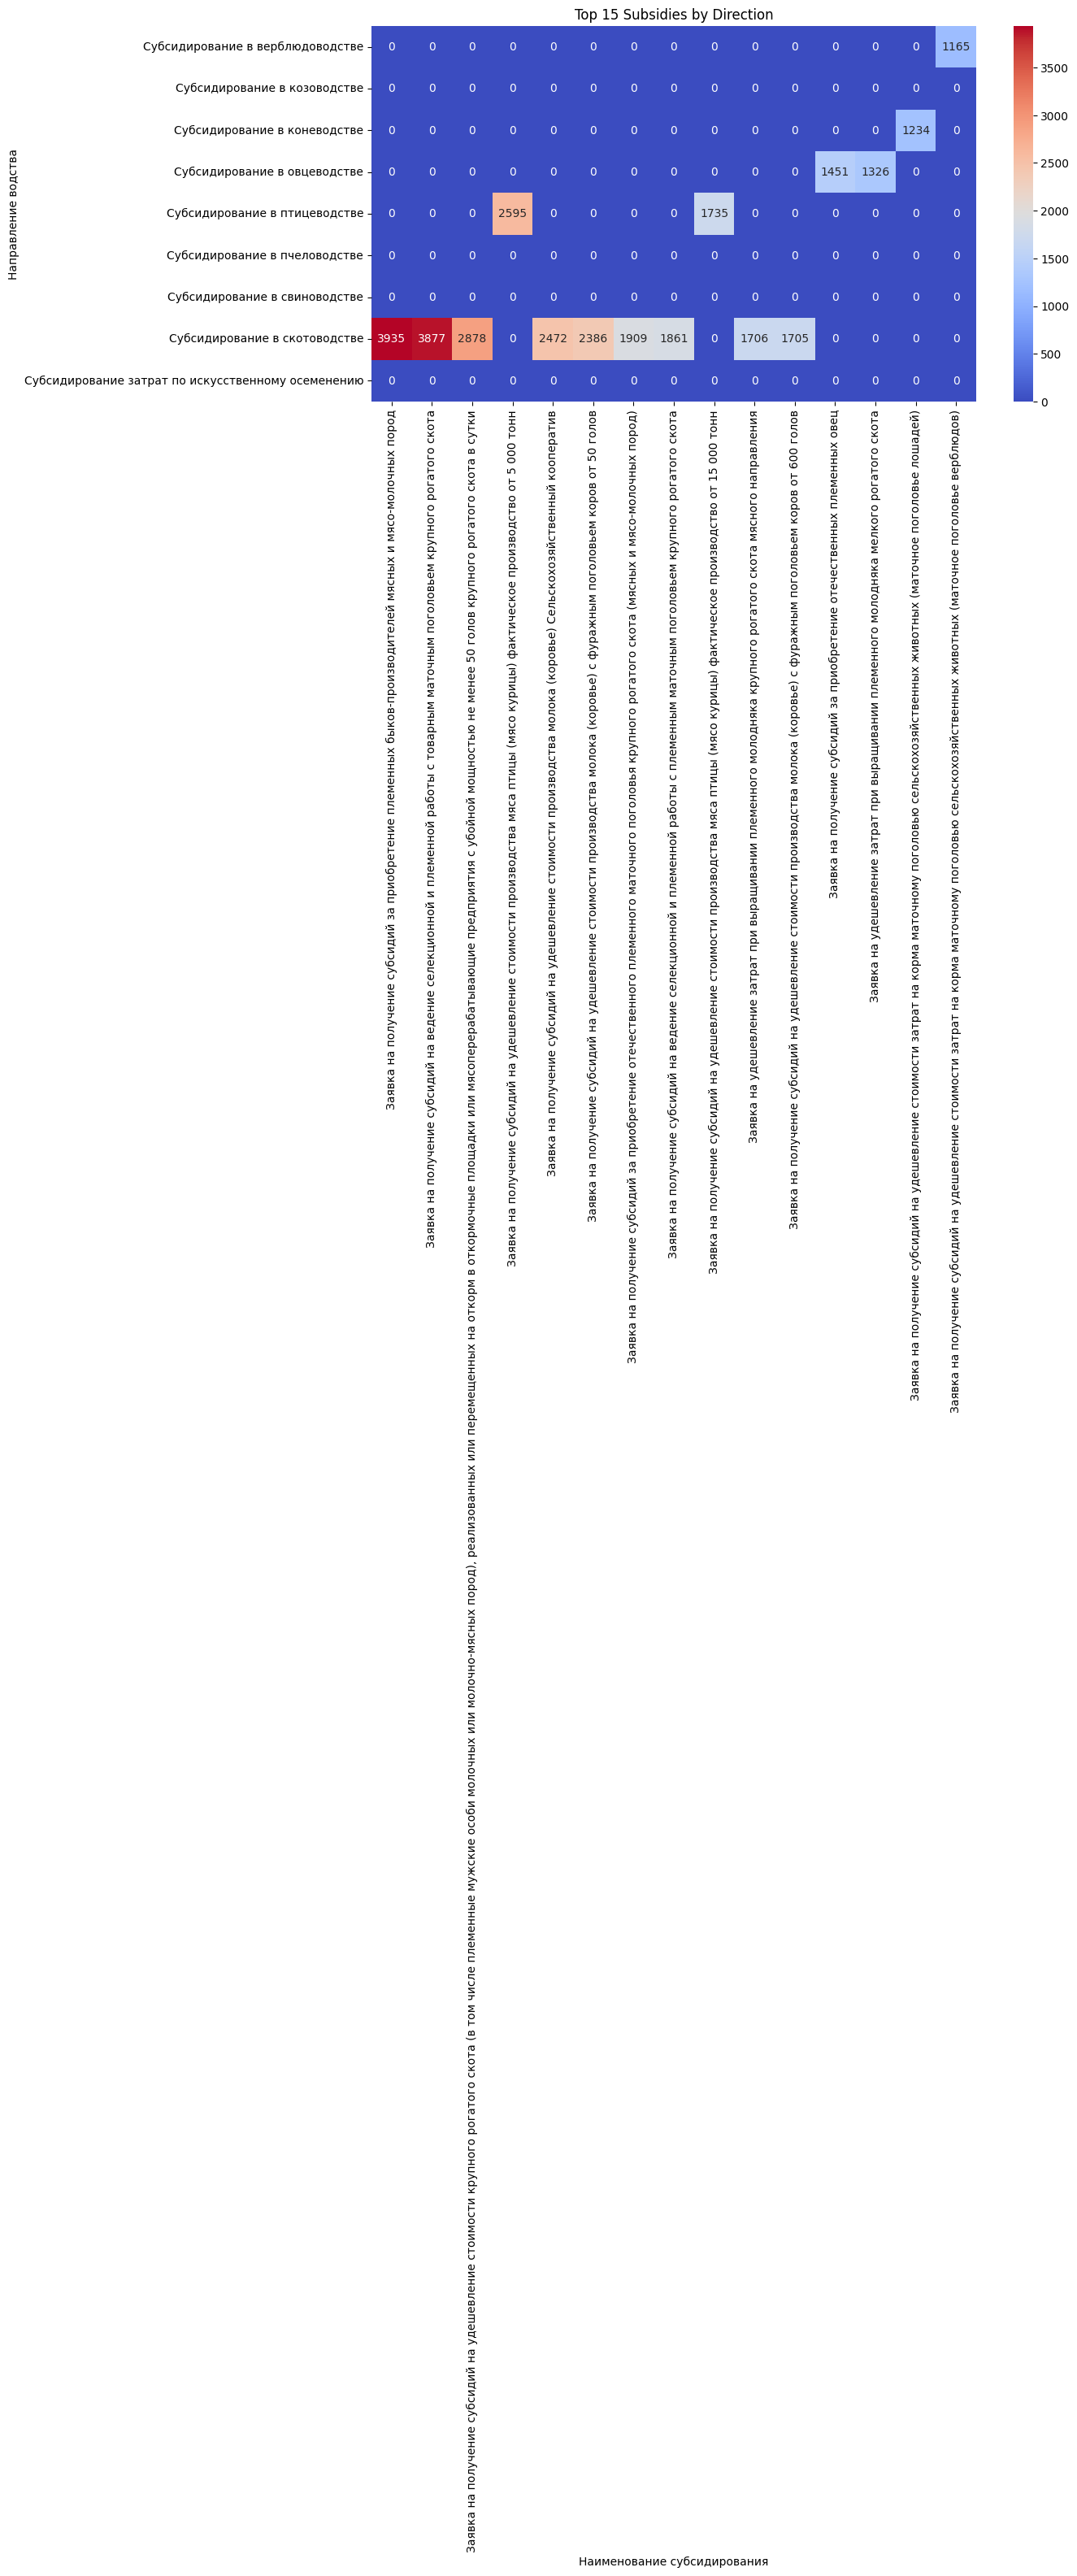

Saved pivot_table.csv ✅
Размер датасета после фильтрации ТОП-15: (32235, 13)


In [3]:
import seaborn as sns
# Выбираем ТОП-15 субсидий
top_15_subsidies = df['Наименование субсидирования'].value_counts().head(15).index

# Строим кросс-таблицу только для ТОП-15
pivot_top = pd.crosstab(
    df['Направление водства'],
    df['Наименование субсидирования']
)[top_15_subsidies]

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_top, annot=True, fmt='d', cmap='coolwarm')
plt.title('Top 15 Subsidies by Direction')
plt.show()

# Сохраняем полную сводную таблицу (как вы и хотели)
pivot_full = pd.crosstab(df['Направление водства'], df['Наименование субсидирования'])
pivot_full.to_csv('/kaggle/working/pivot_table.csv')
print("Saved pivot_table.csv ✅")

# ФИЛЬТРУЕМ ДАТАСЕТ: Оставляем только ТОП-15 для ML-модели
df = df[df['Наименование субсидирования'].isin(top_15_subsidies)].copy()
print(f"Размер датасета после фильтрации ТОП-15: {df.shape}")

In [4]:
def define_target(status):
    status = str(status).lower()
    # Успешные (1)
    if any(x in status for x in ['исполн', 'одобр', 'сформир']): 
        return 1
    # Отклоненные (0)
    elif any(x in status for x in ['отклон', 'отказ', 'отозван']): 
        return 0
    # Новые заявки для скоринга (-1)
    else: 
        return -1 

df['target'] = df['Статус заявки'].apply(define_target)

# Разделяем на Train (история) и Predict (новые)
df_train = df[df['target'] != -1].copy()
df_new = df[df['target'] == -1].copy()

print(f"Исторические заявки для обучения (Train): {df_train.shape[0]}")
print(f"Новые заявки для скоринга (To Predict): {df_new.shape[0]}")

Исторические заявки для обучения (Train): 32091
Новые заявки для скоринга (To Predict): 144


In [5]:
def clean_numeric(series):
    s = series.astype(str).str.replace(r'[^0-9\.\-]', '', regex=True)
    return pd.to_numeric(s, errors='coerce')

for data in [df_train, df_new]:
    data['amount'] = clean_numeric(data['Причитающая сумма'])
    data['normative'] = clean_numeric(data['Норматив'])
    
    # Восстановление размера стада
    data['proxy_herd_size'] = np.where(
        (data['normative'].notna()) & (data['normative'] > 0),
        data['amount'] / data['normative'], 
        np.nan
    )
    
    # Работа с датами
    data['date'] = pd.to_datetime(data['Дата поступления'], dayfirst=True, errors='coerce')
    data['month'] = data['date'].dt.month
    data['day_of_week'] = data['date'].dt.dayofweek

# Рейтинг успешности региона (считаем ТОЛЬКО по Train)
region_success_rates = df_train.groupby('Область')['target'].mean()
global_mean_success = df_train['target'].mean()

df_train['region_success_rate'] = df_train['Область'].map(region_success_rates).fillna(global_mean_success)
df_new['region_success_rate'] = df_new['Область'].map(region_success_rates).fillna(global_mean_success)

# Label Encoding для категорий
le_direction = LabelEncoder()
all_directions = pd.concat([df_train['Направление водства'], df_new['Направление водства']]).astype(str)
le_direction.fit(all_directions)

df_train['direction_encoded'] = le_direction.transform(df_train['Направление водства'].astype(str))
df_new['direction_encoded'] = le_direction.transform(df_new['Направление водства'].astype(str))

In [6]:
features = ['amount', 'normative', 'proxy_herd_size', 'month', 'day_of_week', 
            'region_success_rate', 'direction_encoded']

X = df_train[features]
y = df_train['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Обучение LightGBM...")
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    class_weight='balanced'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

val_preds = model.predict(X_val)
val_probs = model.predict_proba(X_val)[:, 1]

print(f"\nROC-AUC на валидации: {roc_auc_score(y_val, val_probs):.4f}")
print(f"Accuracy на валидации: {accuracy_score(y_val, val_preds):.4f}")

Обучение LightGBM...
[LightGBM] [Info] Number of positive: 22311, number of negative: 3361
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002595 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 568
[LightGBM] [Info] Number of data points in the train set: 25672, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

In [7]:
X_predict = df_new[features]

# Если есть новые заявки для предсказания
if X_predict.shape[0] > 0:
    new_probabilities = model.predict_proba(X_predict)[:, 1]
    df_new['Merit_Score'] = (new_probabilities * 100).round(1)

    result_columns = ['Номер заявки', 'Область', 'Направление водства', 'amount', 'Merit_Score']
    top_recommendations = df_new.sort_values(by='Merit_Score', ascending=False)[result_columns]
    
    print("\nТоп-5 заявок, рекомендованных к одобрению:")
    display(top_recommendations.head(30000))
    top_recommendations.to_excel("/kaggle/working/scored_applications_2025.xlsx", index=False)
    print("Сохранено в scored_applications_2025.xlsx")

    # SHAP Explainability
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_predict)
    
    if isinstance(shap_values, list):
        shap_vals_positive = shap_values[1]
        expected_val = explainer.expected_value[1]
    else:
        shap_vals_positive = shap_values
        expected_val = explainer.expected_value
        
    print("\nФакторы, повлиявшие на балл заявки с самым высоким приоритетом:")
    top_index = top_recommendations.index[0] # Индекс лучшей заявки
    row_idx = X_predict.index.get_loc(top_index) # Локальный индекс для SHAP
    
    shap.force_plot(
        expected_val, 
        shap_vals_positive[row_idx, :], 
        X_predict.iloc[row_idx, :], 
        feature_names=features
    )
else:
    print("В новых данных нет заявок для скоринга (все статусы имеют финальное решение).")


Топ-5 заявок, рекомендованных к одобрению:


,Номер заявки,Область,Направление водства,amount,Merit_Score
36530,5.801000e+12,область Абай,Субсидирование в птицеводстве,1156200.0,95.5
36508,5.801000e+12,область Абай,Субсидирование в птицеводстве,2430840.0,95.4
36522,5.801000e+12,область Абай,Субсидирование в птицеводстве,528000.0,94.5
36286,4.001004e+11,Туркестанская область,Субсидирование в скотоводстве,44200000.0,92.2
36546,4.001004e+11,область Абай,Субсидирование в скотоводстве,3990000.0,91.7
...,...,...,...,...,...
36603,1.900100e+12,Акмолинская область,Субсидирование в скотоводстве,983500.0,25.0
36615,4.001004e+11,Павлодарская область,Субсидирование в скотоводстве,8775000.0,24.6
35082,7.001004e+11,Северо-Казахстанская область,Субсидирование в скотоводстве,2600000.0,23.3
34696,1.900100e+12,Северо-Казахстанская область,Субсидирование в скотоводстве,5201180.0,19.0


Сохранено в scored_applications_2025.xlsx

Факторы, повлиявшие на балл заявки с самым высоким приоритетом:


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# 1. РАСЧЕТ МЕТРИК НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ (на исторических данных, которые модель не видела при обучении)
val_preds = model.predict(X_val) # Предсказываем класс (0 или 1)
val_probs = model.predict_proba(X_val)[:, 1] # Предсказываем вероятность (0.0 - 1.0)

print("=== ОЦЕНКА КАЧЕСТВА МОДЕЛИ ===")
print(f"Accuracy (Точность в целом): {accuracy_score(y_val, val_preds):.4f}")
print(f"Precision (Точность для класса 'Одобрено'): {precision_score(y_val, val_preds):.4f}")
print(f"Recall (Полнота для класса 'Одобрено'): {recall_score(y_val, val_preds):.4f}")
print("-" * 30)

# 2. ФУНКЦИЯ ДЛЯ РУЧНОЙ ПРОВЕРКИ ЗАЯВОК
def check_real_prediction(app_number):
    # Ищем заявку в исторических данных (где есть реальный ответ)
    sample = df_train[df_train['Номер заявки'] == app_number]
    
    if sample.empty:
        print(f"Заявка с номером {app_number} не найдена в обучающей выборке (возможно она отсеялась или это статус 'Получена').")
        return
    
    # Берем фичи этой заявки и делаем предсказание
    sample_features = sample[features]
    prob = model.predict_proba(sample_features)[0, 1]
    score = round(prob * 100, 1)
    
    # Реальный ответ
    real_target = sample['target'].values[0]
    real_status = sample['Статус заявки'].values[0]
    
    print(f"=== ПРОВЕРКА ЗАЯВКИ № {app_number} ===")
    print(f"Регион: {sample['Область'].values[0]}")
    print(f"Сумма: {sample['amount'].values[0]}")
    print(f"Направление: {sample['Направление водства'].values[0]}")
    print("-" * 30)
    print(f"РЕАЛЬНЫЙ СТАТУС: {real_status} (Target: {real_target})")
    print(f"AI MERIT SCORE: {score}/100")
    
    if score >= 50 and real_target == 1:
        print("✅ Модель УГАДАЛА (Одобрила хорошую заявку)")
    elif score < 50 and real_target == 0:
        print("✅ Модель УГАДАЛА (Отклонила плохую заявку)")
    elif score >= 50 and real_target == 0:
        print("❌ ОШИБКА False Positive (Модель одобрила, а в реальности был отказ)")
    else:
        print("❌ ОШИБКА False Negative (Модель забраковала, а в реальности было исполнено)")


=== ОЦЕНКА КАЧЕСТВА МОДЕЛИ ===
Accuracy (Точность в целом): 0.6615
Precision (Точность для класса 'Одобрено'): 0.9362
Recall (Полнота для класса 'Одобрено'): 0.6551
------------------------------


In [9]:
# Обновленная функция проверки с правильным порогом!
def check_real_prediction(app_number, threshold=20): # <-- ПОРОГ ТЕПЕРЬ 20
    # Ищем заявку в исторических данных
    sample = df_train[df_train['Номер заявки'] == app_number]
    
    if sample.empty:
        print(f"Заявка с номером {app_number} не найдена.")
        return
    
    # Берем фичи этой заявки и делаем предсказание
    sample_features = sample[features]
    prob = model.predict_proba(sample_features)[0, 1]
    score = round(prob * 100, 1)
    
    # Реальный ответ
    real_target = sample['target'].values[0]
    real_status = sample['Статус заявки'].values[0]
    
    print(f"=== ПРОВЕРКА ЗАЯВКИ № {app_number} ===")
    print(f"Регион: {sample['Область'].values[0]}")
    print(f"Сумма: {sample['amount'].values[0]}")
    print(f"Направление: {sample['Направление водства'].values[0]}")
    print("-" * 30)
    print(f"РЕАЛЬНЫЙ СТАТУС: {real_status} (Target: {real_target})")
    print(f"AI MERIT SCORE: {score}/100")
    print(f"Текущий порог одобрения: {threshold}")
    
    # ТЕПЕРЬ СРАВНИВАЕМ С THRESHOLD, А НЕ С 50
    if score >= threshold and real_target == 1:
        print("✅ Модель УГАДАЛА (Одобрила хорошую заявку)")
    elif score < threshold and real_target == 0:
        print("✅ Модель УГАДАЛА (Отклонила плохую заявку)")
    elif score >= threshold and real_target == 0:
        print("❌ ОШИБКА False Positive (Модель одобрила, а в реальности был отказ)")
    else:
        print("❌ ОШИБКА False Negative (Модель забраковала, а в реальности было исполнено)")

# Проверяем вашу заявку из Жамбылской области
check_real_prediction(3100200380884.0, threshold=20)

=== ПРОВЕРКА ЗАЯВКИ № 3100200380884.0 ===
Регион: Жамбылская область
Сумма: 7800000.0
Направление: Субсидирование в овцеводстве
------------------------------
РЕАЛЬНЫЙ СТАТУС: Одобрена (Target: 1)
AI MERIT SCORE: 40.1/100
Текущий порог одобрения: 20
✅ Модель УГАДАЛА (Одобрила хорошую заявку)


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Устанавливаем наш найденный оптимальный порог
OPTIMAL_THRESHOLD = 20
threshold_prob = OPTIMAL_THRESHOLD / 100.0

# 1. РАСЧЕТ МЕТРИК С НОВЫМ ПОРОГОМ
val_probs = model.predict_proba(X_val)[:, 1]
custom_preds = (val_probs >= threshold_prob).astype(int) # Применяем порог 20%

print(f"=== ОЦЕНКА КАЧЕСТВА МОДЕЛИ (при пороге {OPTIMAL_THRESHOLD} баллов) ===")
print(f"Accuracy:  {accuracy_score(y_val, custom_preds):.4f}")
print(f"Precision: {precision_score(y_val, custom_preds):.4f} (Защита от плохих заявок)")
print(f"Recall:    {recall_score(y_val, custom_preds):.4f} (Доля одобренных хороших фермеров)")
print(f"F1-Score:  {f1_score(y_val, custom_preds):.4f} (Баланс)")
print("-" * 40)

# 2. ФУНКЦИЯ ДЛЯ РУЧНОЙ ПРОВЕРКИ
def check_real_prediction(app_number, threshold=OPTIMAL_THRESHOLD):
    app_number_clean = str(app_number).strip().replace('.0', '')
    # Ищем заявку (конвертируем колонку в текст для надежного поиска)
    sample = df_train[df_train['Номер заявки'].astype(str).str.replace('.0', '') == app_number_clean]
    
    if sample.empty:
        print(f"Заявка с номером {app_number_clean} не найдена в исторической выборке (Возможно, она в ТОП-15 не вошла или новая).")
        return
    
    sample_features = sample[features]
    prob = model.predict_proba(sample_features)[0, 1]
    score = round(prob * 100, 1)
    
    real_target = sample['target'].values[0]
    real_status = sample['Статус заявки'].values[0]
    
    print(f"=== ПРОВЕРКА ЗАЯВКИ № {app_number_clean} ===")
    print(f"Регион: {sample['Область'].values[0]}")
    print(f"Сумма: {sample['amount'].values[0]} тг")
    print(f"Направление: {sample['Направление водства'].values[0]}")
    print("-" * 30)
    print(f"РЕАЛЬНЫЙ СТАТУС: {real_status} (Target: {real_target})")
    print(f"AI MERIT SCORE: {score}/100")
    print(f"ПОРОГ ОДОБРЕНИЯ: {threshold}")
    
    if score >= threshold and real_target == 1:
        print("✅ УСПЕХ: Модель пропустила хорошего фермера")
    elif score < threshold and real_target == 0:
        print("✅ УСПЕХ: Модель заблокировала плохую заявку")
    elif score >= threshold and real_target == 0:
        print("❌ РИСК (False Positive): Модель одобрила, а в реальности был отказ")
    else:
        print("❌ ЖАЛОБА (False Negative): Модель забраковала, а фермер был хороший")

# --- ТЕСТЫ ---
# Проверяем ту самую проблемную заявку
check_real_prediction("3100200380884")

# Можете раскомментировать строку ниже и вставить любой свой номер для проверки
# check_real_prediction("ВАШ_НОМЕР_ИЗ_ЭКСЕЛЯ")

=== ОЦЕНКА КАЧЕСТВА МОДЕЛИ (при пороге 20 баллов) ===
Accuracy:  0.8684
Precision: 0.8788 (Защита от плохих заявок)
Recall:    0.9842 (Доля одобренных хороших фермеров)
F1-Score:  0.9285 (Баланс)
----------------------------------------
=== ПРОВЕРКА ЗАЯВКИ № 3100200380884 ===
Регион: Жамбылская область
Сумма: 7800000.0 тг
Направление: Субсидирование в овцеводстве
------------------------------
РЕАЛЬНЫЙ СТАТУС: Одобрена (Target: 1)
AI MERIT SCORE: 40.1/100
ПОРОГ ОДОБРЕНИЯ: 20
✅ УСПЕХ: Модель пропустила хорошего фермера
